In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

In [16]:
def sistema(estado):
    x, y = estado
    dXdt = y
    dYdt = -x + y * (1- 3*x**2 - 2*y**2)
    return np.array([dXdt, dYdt])


def euler(x0, y0, t0, tf, h):
    num_pasos = int((tf-t0)/h)
    t = np.linspace(t0, tf, num_pasos+1)
    
    X = np.zeros(num_pasos+1)
    X[0] = x0
    Y = np.zeros(num_pasos+1)
    Y[0] = y0 
    
    for i in range(num_pasos):
        estado = np.array([X[i], Y[i]])
        pendiente = sistema(estado)
        
        X[i+1] = X[i] + h * pendiente[0]
        Y[i+1] = Y[i] + h * pendiente[1]
        
    return t, X, Y


In [49]:
# Campo vectorial
x_vals = np.linspace(-2.2, 2.2, 25)
y_vals = np.linspace(-2.2, 2.2, 25)
X_grid, Y_grid = np.meshgrid(x_vals, y_vals)

U = Y_grid
V = -X_grid + Y_grid * (1 - 3*X_grid**2 - 2*Y_grid**2)

norma = np.sqrt(U**2 + V**2)
norma[norma == 0] = 1

U_norm = U / norma
V_norm = V / norma

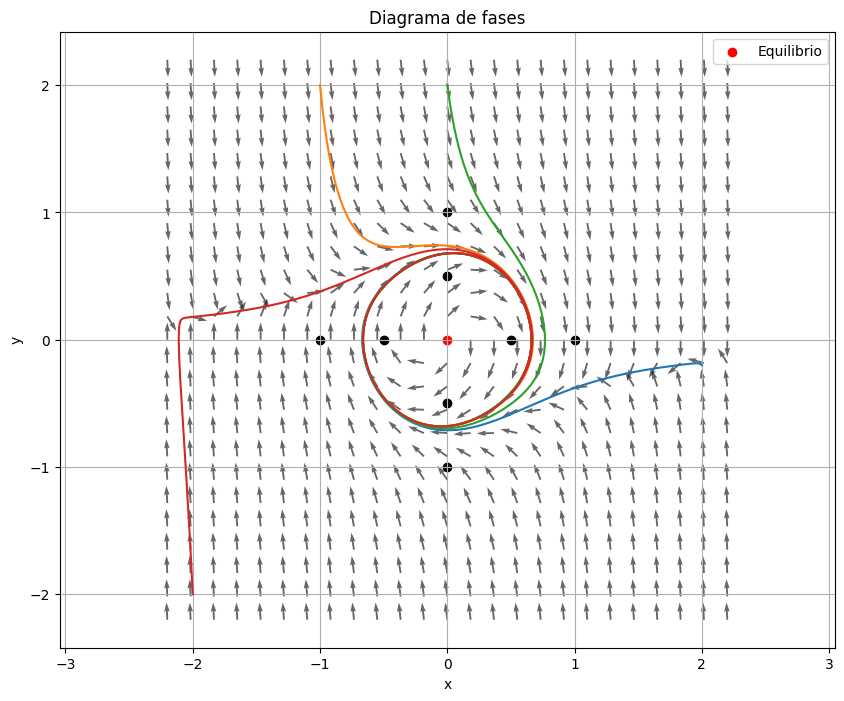

In [50]:
condiciones_iniciales = [(2,-0.2),(-1,2),(0,2),(-2,-2)]

# Gráfico
plt.figure(figsize=(10,8))
plt.quiver(X_grid, Y_grid, U_norm, V_norm, alpha=0.6)
plt.scatter(0, 0, color='red', label='Equilibrio')

plt.scatter(0,0.5,color='black')
plt.scatter(0,-0.5,color='black')
plt.scatter(0.5,0,color='black')
plt.scatter(-0.5,0,color='black')
plt.scatter(1,0,color='black')
plt.scatter(-1,0,color='black')
plt.scatter(0,1,color='black')
plt.scatter(0,-1,color='black')

# Trayectorias
for x0, y0 in condiciones_iniciales:
    t, x, y = euler(x0, y0, 0, 15, 0.01)
    plt.plot(x, y)


plt.title(f'Diagrama de fases')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

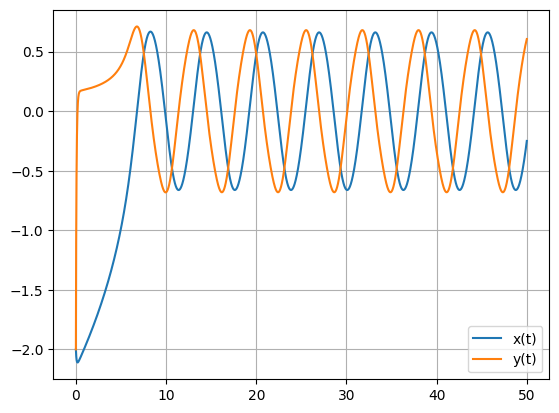

In [51]:
t, x, y = euler(-2, -2, 0, 50, 0.01)
plt.plot(t, x, label='x(t)')
plt.plot(t, y, label='y(t)')
plt.legend()
plt.grid(True)
plt.show()

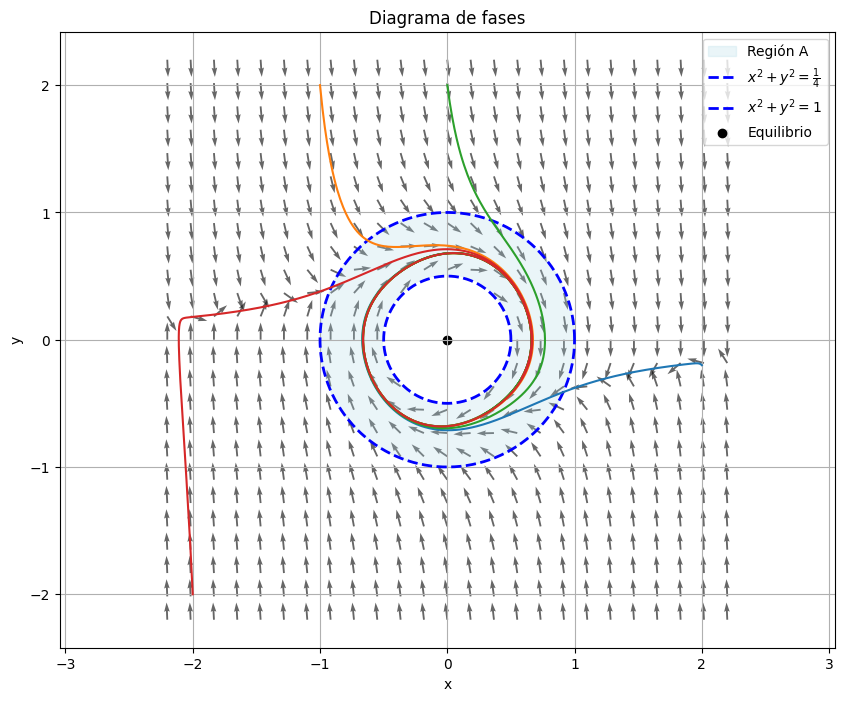

In [55]:
import numpy as np
import matplotlib.pyplot as plt

condiciones_iniciales = [(2, -0.2), (-1, 2), (0, 2), (-2, -2)]

# Ángulo para parametrizar circunferencias
theta = np.linspace(0, 2*np.pi, 400)

# Circunferencia interior: radio 0.5
r_int = 0.5
x_int = r_int * np.cos(theta)
y_int = r_int * np.sin(theta)

# Circunferencia exterior: radio 1
r_ext = 1
x_ext = r_ext * np.cos(theta)
y_ext = r_ext * np.sin(theta)

# Gráfico
plt.figure(figsize=(10, 8))
plt.quiver(X_grid, Y_grid, U_norm, V_norm, alpha=0.6)

# Región A sombreada
plt.fill(x_ext, y_ext, color='lightblue', alpha=0.25, label='Región A')
plt.fill(x_int, y_int, color='white')

# Fronteras de A
plt.plot(x_int, y_int, color='blue', linestyle='--', linewidth=2, label=r'$x^2+y^2=\frac{1}{4}$')
plt.plot(x_ext, y_ext, color='blue', linestyle='--', linewidth=2, label=r'$x^2+y^2=1$')

# Trayectorias
for x0, y0 in condiciones_iniciales:
    t, x, y = euler(x0, y0, 0, 15, 0.01)
    plt.plot(x, y)

plt.scatter(0, 0, color='black', label='Equilibrio')

plt.title('Diagrama de fases')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')   # importante para que los círculos se vean como círculos
plt.grid(True)
plt.legend()
plt.show()